# Imports

In [ ]:
#!pip install pillow-heif


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 47.0 MB/s eta 0:00:00


In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle

from PIL import Image
#import pillow_heif

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#

# **dont need to run it** .HEIC to .jpg convert, ,

# Dataset paths

In [2]:
DATA_DIR = '/content/drive/MyDrive/CVPR_practice/data'

if DATA_DIR is None:
    raise Exception("DATA_DIR is None")


In [3]:


CATEGORIES = sorted(os.listdir(DATA_DIR))
output_unit = len(CATEGORIES)

print("Number of classes:", output_unit)
print("Classes:", CATEGORIES)

Number of classes: 76
Classes: ['21-45902-3', '22-46138-1', '22-46139-1', '22-46141-1', '22-46258-1', '22-46275-1', '22-46293-1', '22-46342-1', '22-46473-1', '22-46536-1', '22-46590-1', '22-46666-1', '22-46679-1', '22-46887-1', '22-46931-1', '22-46983-1', '22-47180-1', '22-47542-2', '22-47813-2', '22-47884-2', '22-47888-2', '22-47892-2', '22-47898-2', '22-47968-2', '22-48005-2', '22-48021-2', '22-48023-2', '22-48055-2', '22-48064-2', '22-48091-2', '22-48133-2', '22-48205-2', '22-48310-3', '22-48354-3', '22-48434-3', '22-48569-3', '22-48582-3', '22-48666-3', '22-48682-3', '22-48725-3', '22-48833-3', '22-48841-3', '22-48915-3', '22-49037-3', '22-49068-3', '22-49167-3', '22-49196-3', '22-49331-3', '22-49338-3', '22-49355-3', '22-49370-3', '22-49421-3', '22-49450-3', '22-49451-3', '22-49453-3', '22-49507-3', '22-49538-3', '22-49575-3', '22-49609-3', '22-49643-3', '22-49745-3', '22-49783-3', '22-49791-3', '22-49800-3', '22-49824-3', '22-49843-3', '22-49852-3', '22-49862-3', '23-50066-1', '2

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50

# Load images

In [5]:
data = []

for label, category in enumerate(CATEGORIES):
    folder_path = os.path.join(DATA_DIR, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            data.append([img, label])
        except:
            print("Error loading:", img_path)


#random.shuffle(data)

Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120607.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120557.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120817.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120541.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120606.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120559.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120551.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120656.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120819.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120548.jpg
Error loading: /content/drive/MyDrive/CVPR_practice/data/22-49068-3/20251227_120609.jpg
Error loading: /content/drive/My

In [6]:
import pickle

pickle_path = "/content/drive/MyDrive/CVPR_practice/all_student_data.pkl"

with open(pickle_path, "wb") as f:
    pickle.dump(data, f)

print("Data saved successfully!")


Data saved successfully!


In [ ]:
pickle_in = open("/content/drive/MyDrive/CVPR_practice/all_data.pkl","rb")
data = pickle.load(pickle_in)
print("Total samples:", len(data))


Total samples: 1126


# Shuffle randomly

In [7]:
random.shuffle(data)

# visualize some data


In [8]:
i = 0
plt.figure(figsize=(20,15))

for i in range(20):
    img_data, label = data[i]
    plt.subplot(4,5,i+1)
    plt.imshow(cv2.cvtColor(img_data, cv2.COLOR_BGR2RGB))
    plt.ylabel(label)
    #plt.xlabel(person)
    plt.xticks([])
    plt.yticks([])
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#X = []
#y = []

#for img, label, category in all_data:
   # X.append(img)
    #y.append(label)

#X = np.array(X, dtype="float32")
#y = np.array(y)


# Normalize

In [9]:
images = np.array([x[0] for x in data], dtype="float32") / 255.0
labels = np.array([x[1] for x in data])

split = int(0.8 * len(images))

X_train, X_test = images[:split], images[split:]
Y_train, Y_test = labels[:split], labels[split:]

print("Train:", X_train.shape, Y_train.shape)
print("Test :", X_test.shape, Y_test.shape)


Train: (916, 224, 224, 3) (916,)
Test : (230, 224, 224, 3) (230,)


# Augmentation

In [10]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(X_train, Y_train, batch_size=BATCH_SIZE)
val_generator = val_datagen.flow(X_test, Y_test, batch_size=BATCH_SIZE)


# Model

In [11]:
model = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # Block 1
    layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(256, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(512, (3,3), padding='same', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(1024, activation='relu'),
   # layers.Dropout(0.5),
    layers.Dense(output_unit, activation='softmax')
])


# Compile

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │   102,761,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 76)             │        77,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,394,188 (398.23 MB)

 Trainable params: 104,392,268 (398.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

# EarlyStopping

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]


# Train the Model

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 592s 20s/step - accuracy: 0.0644 - loss: 118.5043 - val_accuracy: 0.0522 - val_loss: 137.3512 - learning_rate: 0.0010
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 582s 20s/step - accuracy: 0.1456 - loss: 26.8606 - val_accuracy: 0.0478 - val_loss: 41.1129 - learning_rate: 0.0010
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 626s 22s/step - accuracy: 0.2533 - loss: 6.4856 - val_accuracy: 0.0609 - val_loss: 21.6490 - learning_rate: 0.0010
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 631s 22s/step - accuracy: 0.3942 - loss: 3.3702 - val_accuracy: 0.1348 - val_loss: 7.2002 - learning_rate: 0.0010
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 614s 21s/step - accuracy: 0.5335 - loss: 2.2335 - val_accuracy: 0.1478 - val_loss: 5.2368 - learning_rate: 0.0010
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 601s 21s/step - accuracy: 0.5958 - loss: 1.8324 - val_accuracy: 0.1565 - val_loss: 6.3990 - learning_rate: 0.0010
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 593s 20s/step - accuracy: 0.6297 - loss: 1.

KeyboardInterrupt: 

# Plot Accuracy & Loss

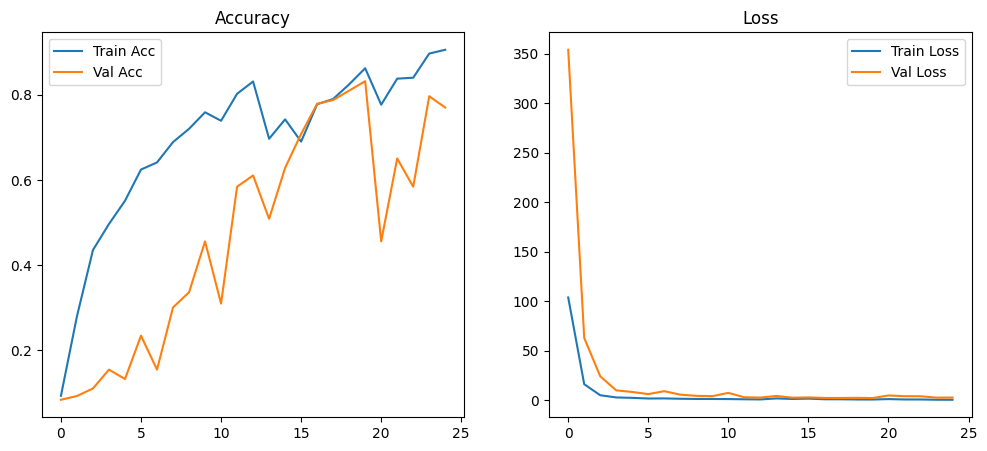

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


# Save the model

In [ ]:
model.save("/content/drive/MyDrive/CVPR_practice/cnn_face_model_latest.keras")

# save the labels

In [16]:
import json
label_map = {i: name for i, name in enumerate(CATEGORIES)}

with open("cnn_face_model_latest_labels.json", "w") as f:
    json.dump(label_map, f)

# Download the model

In [ ]:
train_loss = h.history['loss']
val_loss = h.history['val_loss']
train_acc = h.history['accuracy']
val_acc = h.history['val_accuracy']

In [ ]:
import pickle
from tqdm import tqdm

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_X_train","wb")
pickle.dump(X_train, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_Y_train","wb")
pickle.dump(Y_train, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_X_test","wb")
pickle.dump(X_test, pickle_out)
pickle_out.close()

pickle_out = open("/content/drive/MyDrive/CVPR_practice/facePikle_Y_test","wb")
pickle.dump(Y_test, pickle_out)
pickle_out.close()